In [142]:
import pandas as pd
from collections import defaultdict
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import kruskal
import matplotlib.colors as mcolors

from load_data import load_var, load_all_subjects

In [30]:
def plot_pollutant_with_location_boundaries(data, pollutant='VOC', regime_filter='dynamic'):
    """
    Plots pollutant levels over time, marking location boundaries.

    Parameters:
        data (pd.DataFrame): DataFrame with at least 'object', 'regime', 'location', and the pollutant column.
        pollutant (str): The name of the pollutant column to plot.
        regime_filter (str): One of ['dynamic', 'static', 'all'] to control which regime to display.
    """
    # Validate regime filter
    valid_filters = ['dynamic', 'static', 'all']
    if regime_filter not in valid_filters:
        raise ValueError(f"regime_filter must be one of {valid_filters}")

    # Apply regime filter
    if regime_filter != 'all':
        filtered_data = data[data['regime'] == regime_filter].copy()
    else:
        filtered_data = data.copy()

    # Create a time index per object
    filtered_data['time_index'] = filtered_data.groupby('object').cumcount()

    # Plot each object separately
    for obj in filtered_data['object'].unique():
        subset = filtered_data[filtered_data['object'] == obj].copy()

        # Find where location changes
        subset['location_shift'] = subset['location'].ne(subset['location'].shift())
        location_change_indices = subset.index[subset['location_shift']].tolist()

        # Plotting
        plt.figure(figsize=(14, 6))
        sns.lineplot(data=subset, x='time_index', y=pollutant, hue='location', palette='Set2')

        for idx in location_change_indices:
            x_val = subset.loc[idx, 'time_index']
            loc_label = subset.loc[idx, 'location']
            plt.axvline(x=x_val, color='gray', linestyle='--', alpha=0.6)
            plt.text(x_val, subset[pollutant].max() * 0.95, f"{loc_label}",
                     rotation=90, verticalalignment='top', fontsize=8)

        plt.title(f'Object {obj}: {pollutant} Levels ({regime_filter.capitalize()} Regime)')
        plt.xlabel('Measurement Index')
        plt.ylabel(f'{pollutant} Level')
        plt.grid(True)
        plt.tight_layout()
        plt.show()

In [21]:
voc_all = load_all_subjects('VOC')
voc_all.head()

C:\Python\lib\site-packages\scipy\io\matlab\mio.py:226: MatReadWarning: Duplicate variable name "None" in stream - replacing previous with new
Consider mio5.varmats_from_mat to split file into single variable files
  matfile_dict = MR.get_variables(variable_names)


,S1VOC,S2VOC,S3VOC,S4VOC,S5VOC,S6VOC,S7VOC,S8VOC,S9VOC,S10VOC,S11VOC,S12VOC,S13VOC,S14VOC,S15VOC,S16VOC,S17VOC,S18VOC,S19VOC,S20VOC
sample_index,,,,,,,,,,,,,,,,,,,,
0,173.116797,544.367273,662.446936,850.573868,482.325411,460.310563,638.430731,649.438142,380.256514,702.473946,465.313939,602.406431,513.346341,1233.832431,97.065488,338.228192,593.400355,902.608887,460.310563,800.540111
1,314.751270,594.907695,773.276146,961.515770,548.892438,572.442132,652.256105,667.332273,333.558626,829.610583,477.167145,622.016335,582.996942,1067.482920,128.241707,511.872519,795.322215,941.361974,465.158085,835.454965
2,404.264937,575.449979,748.788057,922.839887,520.532164,591.972740,580.954450,569.043714,282.012376,835.616104,406.400877,524.661942,540.963113,932.459127,152.980714,543.181610,816.255900,840.103773,441.465196,780.226342
3,450.624957,681.341738,844.245371,1023.329966,575.996293,680.522085,740.767218,672.476660,356.574862,956.713436,449.939038,580.593277,585.118745,1104.876414,187.442986,533.906056,869.804754,912.046408,515.447199,918.367465
4,484.043226,660.756421,837.084154,980.060314,545.411377,678.779950,787.030592,662.189422,327.674163,960.767917,414.678092,541.861550,546.211357,994.867419,189.938462,498.092340,864.420519,806.123377,467.932759,885.164843


In [17]:
voc_1 = load_var(1, 'VOC')
voc_1['object'] = 1
voc_1.head()

C:\Python\lib\site-packages\scipy\io\matlab\mio.py:226: MatReadWarning: Duplicate variable name "None" in stream - replacing previous with new
Consider mio5.varmats_from_mat to split file into single variable files
  matfile_dict = MR.get_variables(variable_names)


,VOC,signal,location,regime,object
0,173.116797,0.0,A,static,1
1,181.103727,0.0,A,static,1
2,189.071476,0.0,A,static,1
3,197.006630,0.0,A,static,1
4,204.896420,0.0,A,static,1


In [35]:
def filter_stabilized_dynamic(data, pollutant_col='VOC', window=10, std_threshold=2):
    """
    Filters out the initial spike in dynamic routes and keeps only the stabilized values.

    Parameters:
    - data: DataFrame containing columns ['object', 'location', 'regime', pollutant_col]
    - pollutant_col: the name of the column containing the pollutant level (default is 'VOC')
    - window: the size of the rolling window for statistics (default is 10)
    - std_threshold: the maximum standard deviation in the window to consider the values stable (default is 2)

    Returns:
    - DataFrame: filtered data with stabilized values only
    """
    dynamic_data = data[data['regime'] == 'dynamic']
    filtered = []

    grouped = dynamic_data.groupby(['object', 'location'])

    for (obj, loc), group in grouped:
        group = group.reset_index(drop=True)

        # Calculate rolling standard deviation for the pollutant values
        rolling_std = group[pollutant_col].rolling(window=window).std()

        # Find the first index where the rolling standard deviation is below the threshold
        stable_start = rolling_std[rolling_std < std_threshold].first_valid_index()

        if stable_start is not None:
            # Filter data starting from the point where stability is achieved
            group_filtered = group.iloc[stable_start + window - 1:]  # Shift by the size of the window
            filtered.append(group_filtered)

    # Concatenate all filtered groups and return
    return pd.concat(filtered, ignore_index=True)

In [36]:
voc_filtered = filter_stabilized_dynamic(voc_1, pollutant_col='VOC', window=10, std_threshold=2)

In [37]:
voc_filtered

,VOC,signal,location,regime,object
0,-7.865671e-14,0.0,AB,dynamic,1
1,2.785959e-01,0.0,AB,dynamic,1
2,5.730635e-01,0.0,AB,dynamic,1
3,8.776009e-01,0.0,AB,dynamic,1
4,1.186774e+00,0.0,AB,dynamic,1
...,...,...,...,...,...
3160,2.625218e+01,0.0,GH,dynamic,1
3161,1.946573e+01,0.0,GH,dynamic,1
3162,1.303522e+01,0.0,GH,dynamic,1
3163,6.987132e+00,0.0,GH,dynamic,1


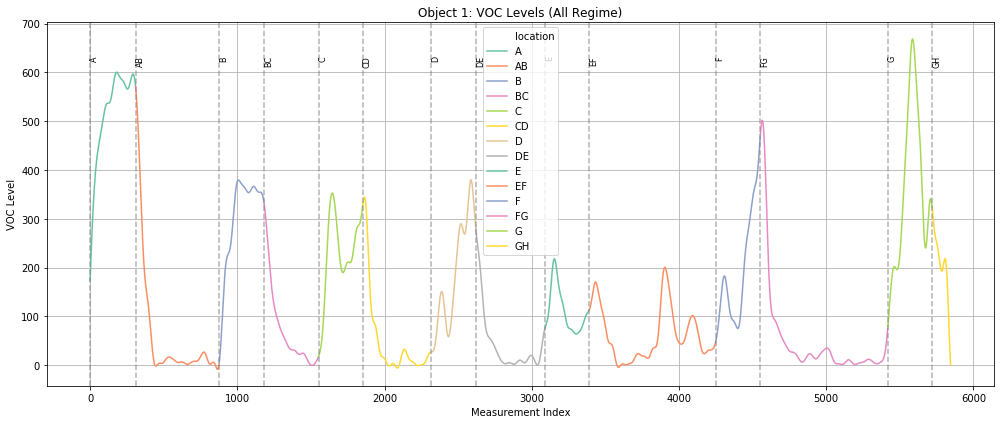

In [32]:
plot_pollutant_with_location_boundaries(voc_1, 'VOC', 'all')

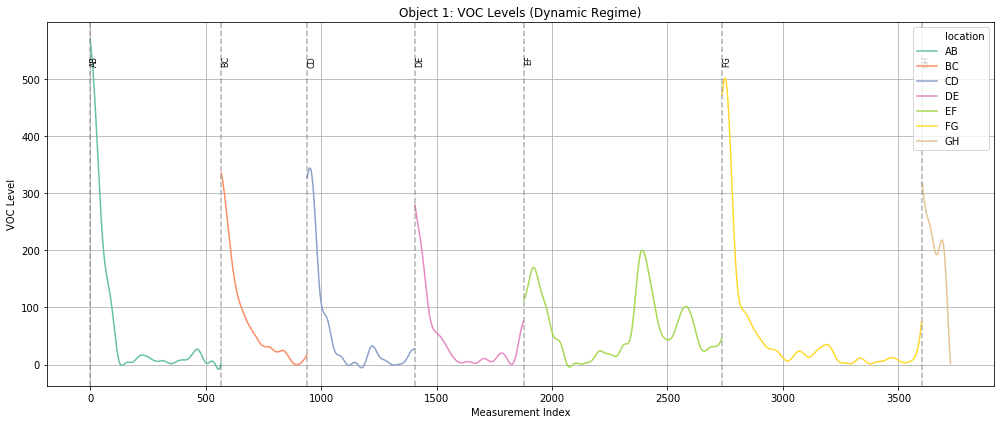

In [33]:
plot_pollutant_with_location_boundaries(voc_1, 'VOC', 'dynamic')

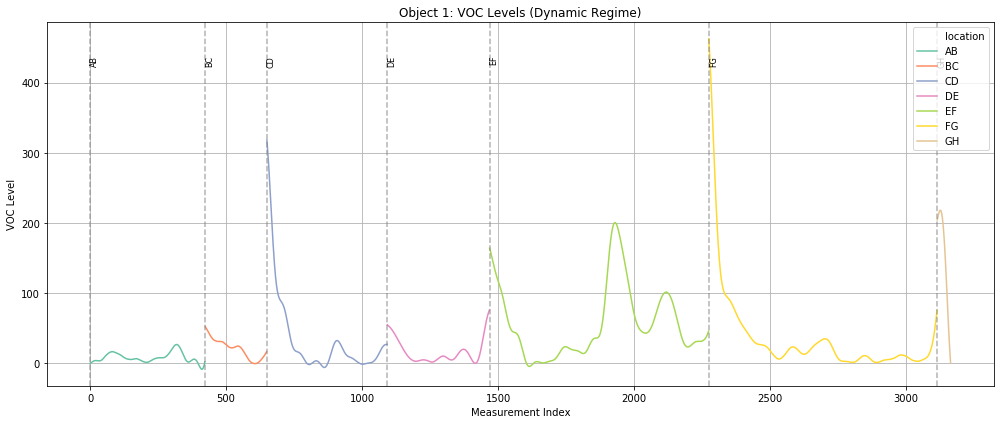

In [38]:
plot_pollutant_with_location_boundaries(voc_filtered, 'VOC', 'dynamic')

In [54]:
def compute_stability_thresholds(data, pollutant_col, last_fraction=0.3, window=10):
    """
    Automatically compute thresholds for std and diff based on the last part of the data,
    assuming it is already stable.
    """
    n = int(len(data) * last_fraction)
    tail = data.iloc[-n:].copy()

    rolling_std_tail = tail[pollutant_col].rolling(window).std()
    rolling_diff_tail = tail[pollutant_col].diff().abs()

    std_threshold = rolling_std_tail.median() + rolling_std_tail.std()
    diff_threshold = rolling_diff_tail.median() + rolling_diff_tail.std()

    return std_threshold, diff_threshold


def is_fully_stable(data, pollutant_col, std_threshold, diff_threshold, window):
    """
    Checks if the entire data sequence is already stable.
    """
    rolling_std = data[pollutant_col].rolling(window).std()
    rolling_diff = data[pollutant_col].diff().abs()

    return (rolling_std.dropna() < std_threshold).all() and (rolling_diff.dropna() < diff_threshold).all()


def find_dynamic_stable_start(data, pollutant_col='VOC', window=10, consecutive_windows=3):
    """
    Automatically detect the start index of the stable portion in a dynamic series.
    If the entire series is stable, returns 0.
    """
    std_threshold, diff_threshold = compute_stability_thresholds(data, pollutant_col, window=window)

    if is_fully_stable(data, pollutant_col, std_threshold, diff_threshold, window):
        return 0  # Entire segment is already stable

    rolling_std = data[pollutant_col].rolling(window).std()
    rolling_diff = data[pollutant_col].diff().abs()

    stable_flags = (rolling_std < std_threshold) & (rolling_diff < diff_threshold)

    for i in range(window - 1, len(data) - consecutive_windows):
        if stable_flags.iloc[i:i + consecutive_windows].all():
            return i + consecutive_windows

    return None

def filter_auto_stable_dynamic(data, pollutant_col='VOC', window=10, consecutive_windows=3):
    """
    Filters only the stable portion of dynamic data per object and location,
    using data-driven thresholds.
    """
    dynamic_data = data[data['regime'] == 'dynamic']
    filtered = []

    grouped = dynamic_data.groupby(['object', 'location'])

    for (obj, loc), group in grouped:
        group = group.reset_index(drop=True)

        stable_start = find_dynamic_stable_start(group, pollutant_col, window, consecutive_windows)

        if stable_start is not None:
            group_filtered = group.iloc[stable_start:]
            filtered.append(group_filtered)

    return pd.concat(filtered, ignore_index=True)

# Analyze VOC differences between locations (example for 1 object)

In [132]:
voc_autofiltered = filter_auto_stable_dynamic(voc_1, window=10, pollutant_col='VOC')

Before filtering

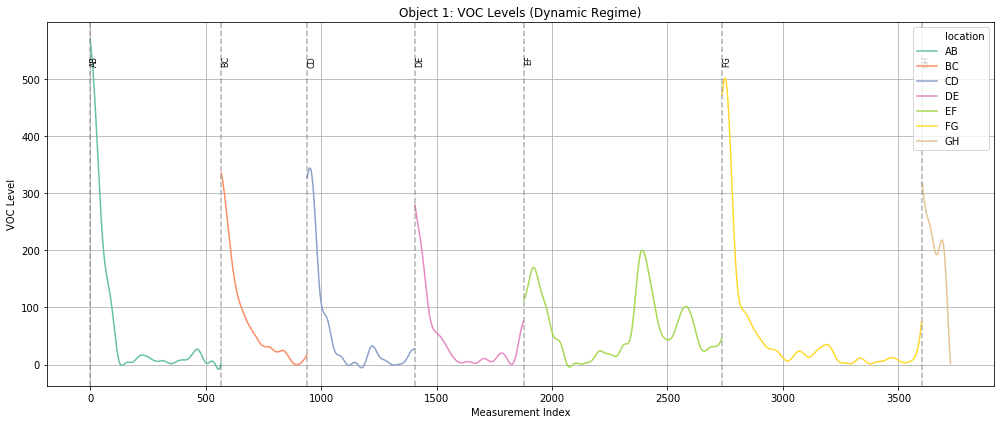

In [42]:
plot_pollutant_with_location_boundaries(voc_1, 'VOC', 'dynamic')

After filtering

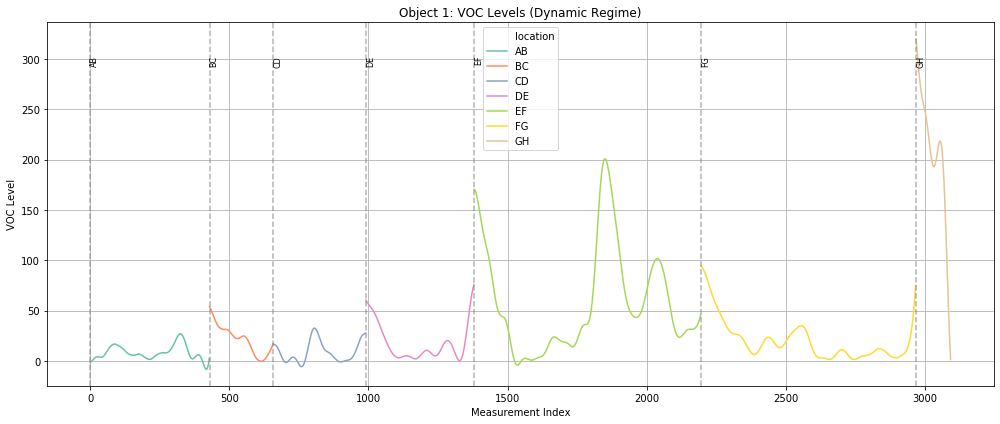

In [56]:
plot_pollutant_with_location_boundaries(voc_autofiltered, 'VOC', 'dynamic')

In [57]:
def plot_pollutant_across_locations(data, pollutant_col='VOC'):

    plt.figure(figsize=(12, 6))
    sns.boxplot(x='location', y=pollutant_col, data=data)
    plt.title('VOC levels across locations (dynamic mode)')
    plt.xlabel('Location')
    plt.ylabel(pollutant_col)
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()

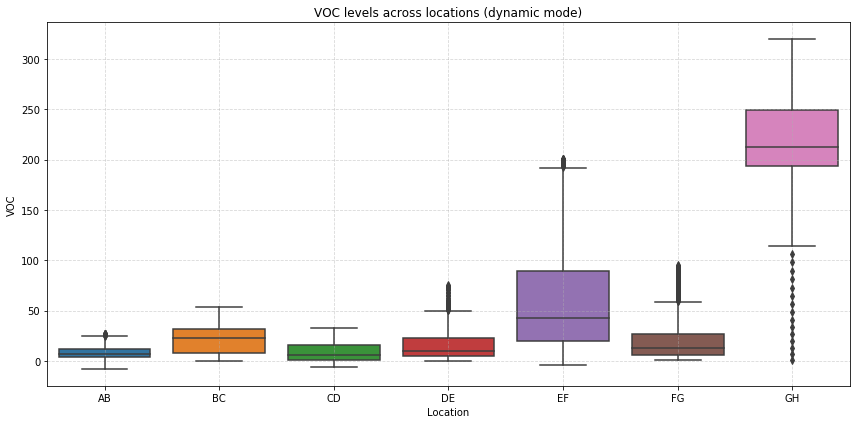

In [58]:
plot_voc_across_locations(voc_autofiltered, pollutant_col='VOC')

In [66]:
def test_pollutant_across_locations(data, pollutant_col='VOC'):
    dynamic_data = data[data['regime'] == 'dynamic']
    groups = [group[pollutant_col].values for _, group in dynamic_data.groupby('location')]
    
    stat, p_value = kruskal(*groups)
    print(f"Kruskal-Wallis test statistic: {stat:.4f}, p-value: {p_value}")
    if p_value < 0.05:
        print("VOC levels differ significantly between locations.")
    else:
        print("No significant difference in VOC levels between locations.")

In [67]:
test_pollutant_across_locations(voc_autofiltered)

Kruskal-Wallis test statistic: 1023.3978, p-value: 7.774894703347205e-218
VOC levels differ significantly between locations.


In [72]:
from scipy.stats import mannwhitneyu
from itertools import combinations
import statsmodels.stats.multicomp as mc

In [75]:
def pairwise_with_statsmodels(data, pollutant_col='VOC'):
    comp = mc.MultiComparison(data[pollutant_col], data['location'])
    result = comp.allpairtest(mannwhitneyu, method='bonferroni')
    return result[0]

In [110]:
pairwise_table = pairwise_with_statsmodels(voc_autofiltered)
pairwise_table

group1,group2,stat,pval,pval_corr,reject
AB,BC,23720.0,0.0,0.0,True
AB,CD,76632.0,0.0843,1.0,False
AB,DE,61222.0,0.0,0.0,True
AB,EF,49188.0,0.0,0.0,True
AB,FG,101156.0,0.0,0.0,True
AB,GH,729.0,0.0,0.0,True
BC,CD,57273.0,0.0,0.0,True
BC,DE,52892.0,0.0001,0.0021,True
BC,EF,51474.0,0.0,0.0,True
BC,FG,99594.0,0.004,0.083,False


In [111]:
data = pairwise_table.data[1:]  
columns = ['group1', 'group2', 'stat', 'pval', 'pval_corr', 'reject']

pairwise_table = pd.DataFrame(data, columns=columns)
pairwise_table.head()

,group1,group2,stat,pval,pval_corr,reject
0,AB,BC,23720.0,0.0000,0.0,True
1,AB,CD,76632.0,0.0843,1.0,False
2,AB,DE,61222.0,0.0000,0.0,True
3,AB,EF,49188.0,0.0000,0.0,True
4,AB,FG,101156.0,0.0000,0.0,True


In [125]:
def plot_pairwise_heatmap(df, pval_col='pval_corr'):

    pivot_table = df.pivot(index='group1', columns='group2', values=pval_col)

    plt.figure(figsize=(10, 8))  
    heatmap = sns.heatmap(pivot_table, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5, vmin=0, vmax=1)

    plt.title('Pairwise Comparison Heatmap', fontsize=16)
    plt.xlabel('Group 2', fontsize=12)
    plt.ylabel('Group 1', fontsize=12)

    plt.tight_layout()  
    plt.show()

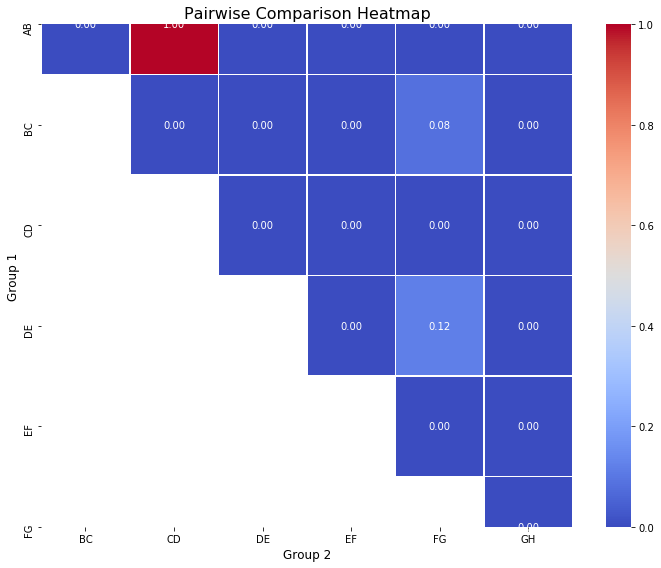

In [126]:
plot_pairwise_heatmap(pairwise_table)

# Analyze VOC differences between locations across all objects

In [133]:
def analyze_locations_across_objects(num_objects=20, pollutant_col='VOC', window=10):
    all_voc = []

    # Step 1–2: Load and filter data for each object
    for i in range(1, num_objects + 1):
        voc_i = load_var(i, pollutant_col)
        voc_i['object'] = i
        voc_filtered = filter_auto_stable_dynamic(voc_i, window=window, pollutant_col=pollutant_col)
        all_voc.append(voc_filtered)

    # Step 3: Concatenate all filtered data
    voc_all = pd.concat(all_voc, ignore_index=True)

    # Step 4: Calculate mean VOC per object per location
    voc_grouped = voc_all.groupby(['object', 'location'])[pollutant_col].mean().reset_index()
    voc_pivot = voc_grouped.pivot(index='object', columns='location', values=pollutant_col)

    # Step 5: Plot heatmap of mean VOC levels per object/location
    plt.figure(figsize=(10, 6))
    sns.heatmap(voc_pivot, annot=True, cmap="YlOrRd", fmt=".1f")
    plt.title("Mean VOC per Object and Location")
    plt.xlabel("Location")
    plt.ylabel("Object")
    plt.tight_layout()
    plt.show()

    # Step 6: Plot individual object VOC and average line plot
    plt.figure(figsize=(12, 6))
    for obj in voc_pivot.index:
        plt.plot(voc_pivot.columns, voc_pivot.loc[obj], alpha=0.3, label=f'Object {obj}')

    # Mean line
    mean_values = voc_pivot.mean(axis=0)
    plt.plot(voc_pivot.columns, mean_values, color='black', label='Mean', linewidth=2)
    plt.title("VOC per Location across Objects")
    plt.xlabel("Location")
    plt.ylabel(f"Mean {pollutant_col}")
    plt.legend()
    plt.tight_layout()
    plt.show()

    return voc_pivot

C:\Python\lib\site-packages\scipy\io\matlab\mio.py:226: MatReadWarning: Duplicate variable name "None" in stream - replacing previous with new
Consider mio5.varmats_from_mat to split file into single variable files
  matfile_dict = MR.get_variables(variable_names)


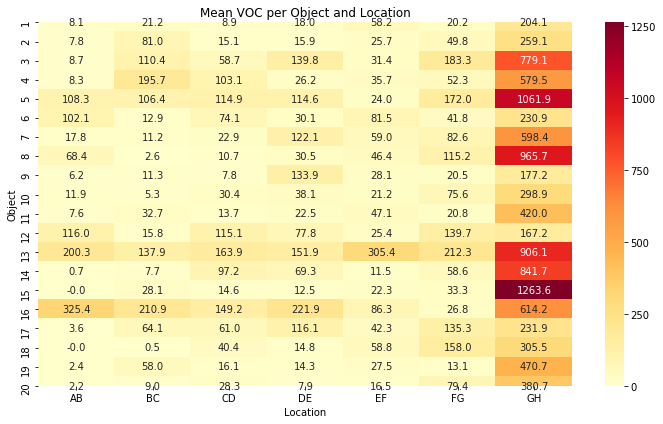

C:\Python\lib\site-packages\matplotlib\cbook\__init__.py:1402: FutureWarning: Support for multi-dimensional indexing (e.g. `obj[:, None]`) is deprecated and will be removed in a future version.  Convert to a numpy array before indexing instead.
  x[:, None]
C:\Python\lib\site-packages\matplotlib\axes\_base.py:276: FutureWarning: Support for multi-dimensional indexing (e.g. `obj[:, None]`) is deprecated and will be removed in a future version.  Convert to a numpy array before indexing instead.
  x = x[:, np.newaxis]
C:\Python\lib\site-packages\matplotlib\axes\_base.py:278: FutureWarning: Support for multi-dimensional indexing (e.g. `obj[:, None]`) is deprecated and will be removed in a future version.  Convert to a numpy array before indexing instead.
  y = y[:, np.newaxis]


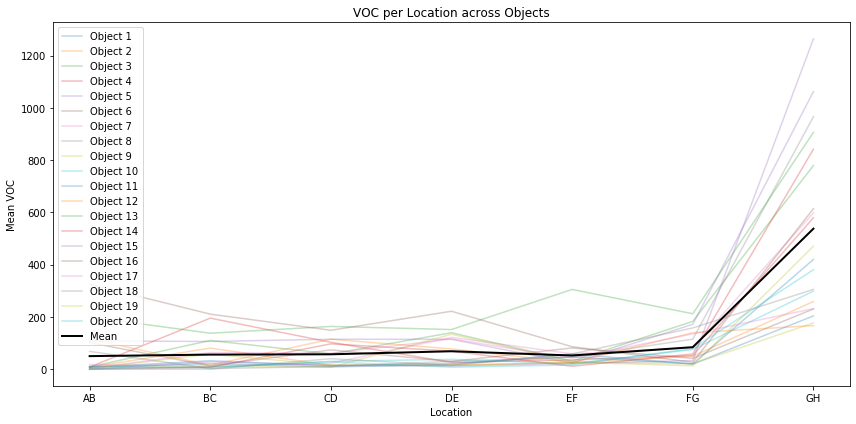

location,AB,BC,CD,DE,EF,FG,GH
object,,,,,,,
1,8.105600,21.223017,8.904690,17.975055,58.172157,20.243526,204.129209
2,7.783775,81.034325,15.138568,15.873548,25.712864,49.756516,259.132022
3,8.699674,110.352801,58.745665,139.810328,31.402653,183.255540,779.117988
4,8.296879,195.662296,103.091007,26.209586,35.715337,52.273535,579.521908
5,108.335383,106.367054,114.858211,114.637753,24.037733,172.019863,1061.919317
6,102.055848,12.931955,74.079247,30.075436,81.483332,41.820372,230.882674
7,17.795113,11.194247,22.873040,122.096431,59.045774,82.556928,598.390332
8,68.368782,2.550523,10.708409,30.450169,46.365159,115.186166,965.677466
9,6.234025,11.344512,7.812385,133.936802,28.141617,20.524952,177.232037


In [134]:
analyze_locations_across_objects()

In [153]:
def remove_outlier_pvals(pvals, threshold=1.5):
    pvals = np.array(pvals)
    eps = 1e-10  
    log_pvals = -np.log10(np.clip(pvals, eps, 1)) 
    
    median = np.median(log_pvals)
    mad = np.median(np.abs(log_pvals - median))  
    if mad == 0:
        return pvals  
    
    z_scores = np.abs(log_pvals - median) / (mad * 1.4826)  
    return pvals[z_scores < z_thresh]

In [158]:
def analyze_location_differences_across_objects(objects=range(1, 21), pollutant_col='VOC', remove_outlier=False):
    all_pvals = defaultdict(list)

    for obj_id in objects:
        # 1. Load and label data
        data = load_var(obj_id, pollutant_col)
        data['object'] = obj_id

        # 2. Filter dynamic stable data
        filtered = filter_auto_stable_dynamic(data, window=10, pollutant_col=pollutant_col)

        # 3. Compare location pairs
        result_table = pairwise_with_statsmodels(filtered, pollutant_col=pollutant_col)

        # 4. Parse result_table into DataFrame
        rows = result_table.data[1:]
        df = pd.DataFrame(rows, columns=['group1', 'group2', 'stat', 'pval', 'pval_corr', 'reject'])

        # 5. Convert values to numeric
        df['pval_corr'] = pd.to_numeric(df['pval_corr'], errors='coerce')

        # 6. Store values in both directions (symmetric)
        for _, row in df.iterrows():
            loc1 = row['group1']
            loc2 = row['group2']
            pval = row['pval_corr']
            if pd.notnull(pval):
                all_pvals[(loc1, loc2)].append(pval)
                all_pvals[(loc2, loc1)].append(pval)

    # 7. Get unique locations
    unique_locations = sorted({loc for pair in all_pvals.keys() for loc in pair})

    # 8. Create matrix with average pval_corr (без выбросов)
    heatmap_data = pd.DataFrame(index=unique_locations, columns=unique_locations, dtype=float)

    for (loc1, loc2), pvals in all_pvals.items():
        if remove_outlier:
            pvals = remove_outlier_pvals(pvals)
        if len(pvals) > 0:
            heatmap_data.loc[loc1, loc2] = np.mean(pvals)
        else:
            heatmap_data.loc[loc1, loc2] = np.nan

    cmap = mcolors.ListedColormap(["#67001f", "#f7f7f7"])
    bounds = [0, 0.05, 1.01]
    norm = mcolors.BoundaryNorm(bounds, cmap.N)

    # 9. Plot heatmap
    plt.figure(figsize=(10, 8))
    sns.heatmap(
        heatmap_data,
        annot=True,
        fmt=".3f",
        cmap=cmap,
        norm=norm,
        linewidths=0.5,
        linecolor='grey',
        cbar_kws={"label": "Average corrected p-value (without outliers)"}
    )
    plt.title("Average Corrected p-values Between Locations (Outliers Removed)")
    plt.tight_layout()
    plt.show()

    return heatmap_data

C:\Python\lib\site-packages\scipy\io\matlab\mio.py:226: MatReadWarning: Duplicate variable name "None" in stream - replacing previous with new
Consider mio5.varmats_from_mat to split file into single variable files
  matfile_dict = MR.get_variables(variable_names)


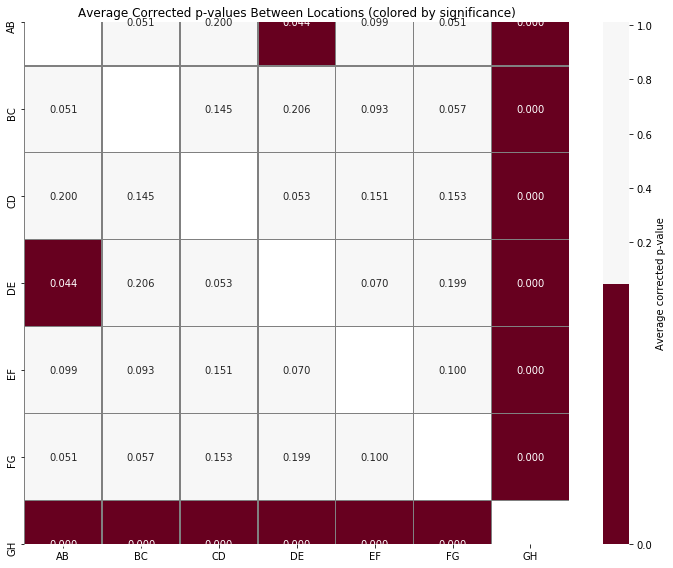

,AB,BC,CD,DE,EF,FG,GH
AB,NaN,0.051335,0.200080,0.043685,0.099250,0.050665,0.000000
BC,0.051335,NaN,0.145055,0.205610,0.092985,0.057300,0.000000
CD,0.200080,0.145055,NaN,0.052925,0.151105,0.153050,0.000000
DE,0.043685,0.205610,0.052925,NaN,0.069650,0.199450,0.000000
EF,0.099250,0.092985,0.151105,0.069650,NaN,0.100000,0.000000
FG,0.050665,0.057300,0.153050,0.199450,0.100000,NaN,0.000005
GH,0.000000,0.000000,0.000000,0.000000,0.000000,0.000005,NaN


In [148]:
analyze_location_differences_across_objects()

- GH is consistently significantly different from all others, indicating a unique environment or behavior.
- AB, BC, DE locations have moderate p-values with both Group 3 and each other. They likely represent transition areas or zones with variable conditions.
- CD, EF, FG locations show non-significant differences between each other, suggesting similar environmental characteristics.

C:\Python\lib\site-packages\scipy\io\matlab\mio.py:226: MatReadWarning: Duplicate variable name "None" in stream - replacing previous with new
Consider mio5.varmats_from_mat to split file into single variable files
  matfile_dict = MR.get_variables(variable_names)


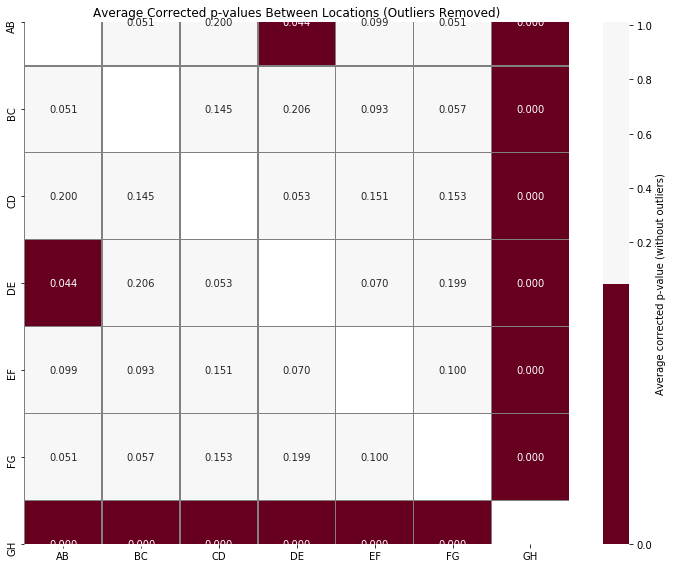

,AB,BC,CD,DE,EF,FG,GH
AB,NaN,0.051335,0.200080,0.043685,0.099250,0.050665,0.000000
BC,0.051335,NaN,0.145055,0.205610,0.092985,0.057300,0.000000
CD,0.200080,0.145055,NaN,0.052925,0.151105,0.153050,0.000000
DE,0.043685,0.205610,0.052925,NaN,0.069650,0.199450,0.000000
EF,0.099250,0.092985,0.151105,0.069650,NaN,0.100000,0.000000
FG,0.050665,0.057300,0.153050,0.199450,0.100000,NaN,0.000005
GH,0.000000,0.000000,0.000000,0.000000,0.000000,0.000005,NaN


In [159]:
analyze_location_differences_across_objects(remove_outlier=True)

C:\Python\lib\site-packages\scipy\io\matlab\mio.py:226: MatReadWarning: Duplicate variable name "None" in stream - replacing previous with new
Consider mio5.varmats_from_mat to split file into single variable files
  matfile_dict = MR.get_variables(variable_names)


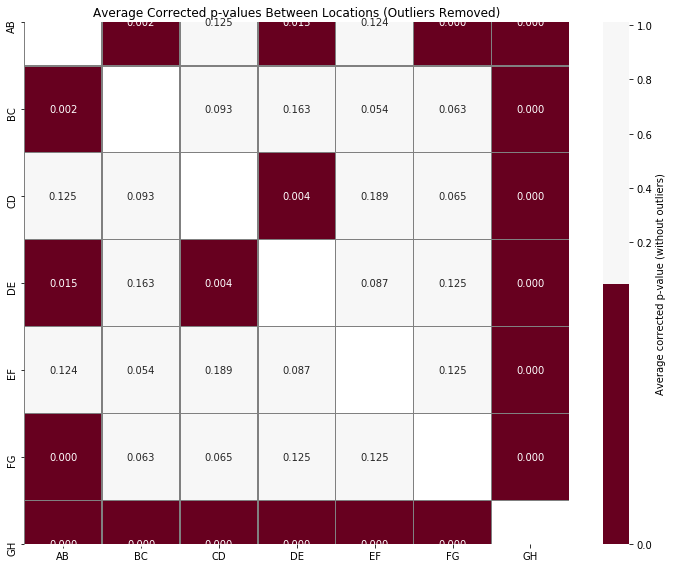

,AB,BC,CD,DE,EF,FG,GH
AB,NaN,0.001669,0.125100,0.015137,0.124062,0.000000,0.0
BC,0.001669,NaN,0.093500,0.163425,0.053731,0.062613,0.0
CD,0.125100,0.093500,NaN,0.003656,0.188881,0.064662,0.0
DE,0.015137,0.163425,0.003656,NaN,0.087063,0.125000,0.0
EF,0.124062,0.053731,0.188881,0.087063,NaN,0.125000,0.0
FG,0.000000,0.062613,0.064662,0.125000,0.125000,NaN,0.0
GH,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,NaN


In [160]:
analyze_location_differences_across_objects([2, 3, 4, 6, 7, 8, 9, 10, 11, 14, 15, 16, 17, 18, 19, 20])